Using a Variational Autoencoder for Compression and Denoising

## Objective :

The objective of this assignment is to explore two practical applications of a VAE:

• Data compression

• Image denoising

## Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Load MNIST dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


## Preprocess the images

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 784)
Test shape: (10000, 784)


## Create VAE with latent dimension = 2

In [ ]:
class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=-1
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

## Function to build VAE

In [ ]:
def build_vae(latent_dim):

    # =========================
    # ENCODER
    # =========================

    encoder_inputs = keras.Input(
        shape=(784,)
    )

    x = layers.Dense(
        256,
        activation="relu"
    )(encoder_inputs)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    z_mean = layers.Dense(
        latent_dim,
        name="z_mean"
    )(x)

    z_log_var = layers.Dense(
        latent_dim,
        name="z_log_var"
    )(x)

    def sampling(args):

        z_mean, z_log_var = args

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var) * epsilon
        )

    z = layers.Lambda(
        sampling,
        name="z"
    )([z_mean, z_log_var])

    encoder = keras.Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name=f"encoder_{latent_dim}"
    )

    # =========================
    # DECODER
    # =========================

    latent_inputs = keras.Input(
        shape=(latent_dim,)
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(latent_inputs)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    decoder_outputs = layers.Dense(
        784,
        activation="sigmoid"
    )(x)

    decoder = keras.Model(
        latent_inputs,
        decoder_outputs,
        name=f"decoder_{latent_dim}"
    )

    # =========================
    # VAE
    # =========================

    vae = VAE(
        encoder,
        decoder,
        name=f"vae_{latent_dim}"
    )

    vae.compile(
        optimizer=keras.optimizers.Adam()
    )

    return encoder, decoder, vae

## Create VAE with latent dimension 2

In [ ]:
latent_dim = 2

encoder2, decoder2, vae2 = build_vae(latent_dim)

print("VAE with latent dimension 2 created successfully!")

VAE with latent dimension 2 created successfully!


## Train VAE with latent dimension 2

In [ ]:
history2 = vae2.fit(
    x_train,
    epochs=20,
    batch_size=128
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - kl_loss: 1.3971 - loss: 34.4683 - reconstruction_loss: 33.0713
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - kl_loss: 2.0252 - loss: 30.7237 - reconstruction_loss: 28.6986
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - kl_loss: 2.3588 - loss: 30.1103 - reconstruction_loss: 27.7515
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 2.5501 - loss: 29.7478 - reconstruction_loss: 27.1977
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.7331 - loss: 29.4480 - reconstruction_loss: 26.7150
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 2.9342 - loss: 29.1553 - reconstruction_loss: 26.2211
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 3.0894 - loss: 28.9374 - reconstruction_loss: 25.8480
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - kl_loss: 3.2012 - loss: 28.7790 - reconstruction_loss: 25.5778
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/s

## Select 10 test images

In [ ]:
test_images = x_test[:10]

print("Selected images:", test_images.shape)

Selected images: (10, 784)


## Encode and decode the 10 images

In [ ]:
z_mean2, z_log_var2, z2 = encoder2.predict(
    test_images
)

reconstructed2 = decoder2.predict(
    z2
)

print("Original shape:", test_images.shape)
print("Latent shape:", z2.shape)
print("Reconstructed shape:", reconstructed2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Original shape: (10, 784)
Latent shape: (10, 2)
Reconstructed shape: (10, 784)


## PART A — COMPRESSION
## Calculate compression ratio

In [ ]:
original_size = 784
latent_size_2 = 2

compression_ratio_2 = original_size / latent_size_2

print("Original MNIST image size:", original_size)
print("Latent representation size:", latent_size_2)
print("Compression ratio:", compression_ratio_2, ":1")

Original MNIST image size: 784
Latent representation size: 2
Compression ratio: 392.0 :1


## PART B — RECONSTRUCTION
## Calculate MSE for 10 images

In [ ]:
mse_values_2 = []

for i in range(10):

    mse = mean_squared_error(
        test_images[i],
        reconstructed2[i]
    )

    mse_values_2.append(mse)

    print(
        f"Image {i+1}: MSE = {mse:.6f}"
    )

average_mse_2 = np.mean(mse_values_2)

print()
print("Average Reconstruction MSE:", average_mse_2)

Image 1: MSE = 0.018844
Image 2: MSE = 0.065127
Image 3: MSE = 0.005966
Image 4: MSE = 0.033583
Image 5: MSE = 0.037297
Image 6: MSE = 0.009020
Image 7: MSE = 0.059961
Image 8: MSE = 0.053111
Image 9: MSE = 0.095507
Image 10: MSE = 0.031124

Average Reconstruction MSE: 0.040953934704884884


## Display original vs reconstructed

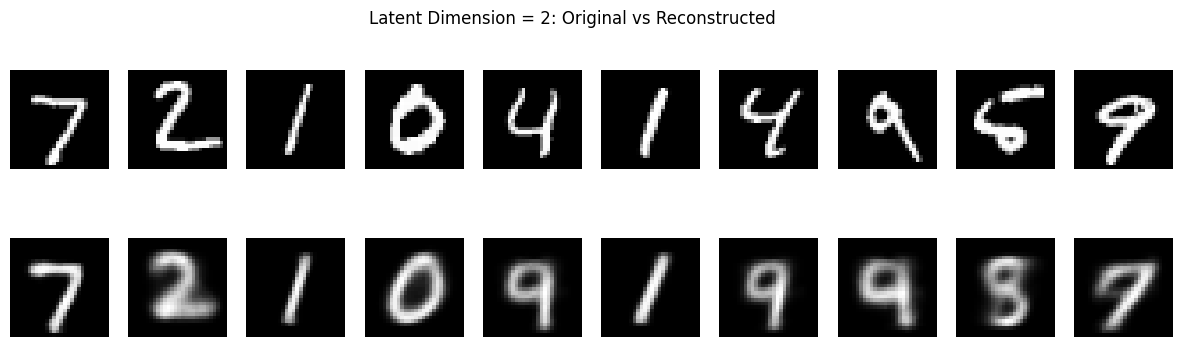

In [ ]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed2[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Latent Dimension = 2: Original vs Reconstructed"
)

plt.show()

## PART C — DENOISING
## Add Gaussian noise

In [ ]:
noise_factor = 0.3

noisy_images = (
    test_images
    + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=test_images.shape
    )
)

noisy_images = np.clip(
    noisy_images,
    0.0,
    1.0
)

print("Gaussian noise added successfully!")

Gaussian noise added successfully!


## Denoise using VAE

In [ ]:
z_mean_noisy, z_log_var_noisy, z_noisy = encoder2.predict(
    noisy_images
)

denoised_images = decoder2.predict(
    z_noisy
)

print("Denoising completed!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Denoising completed!


## Display original, noisy and denoised

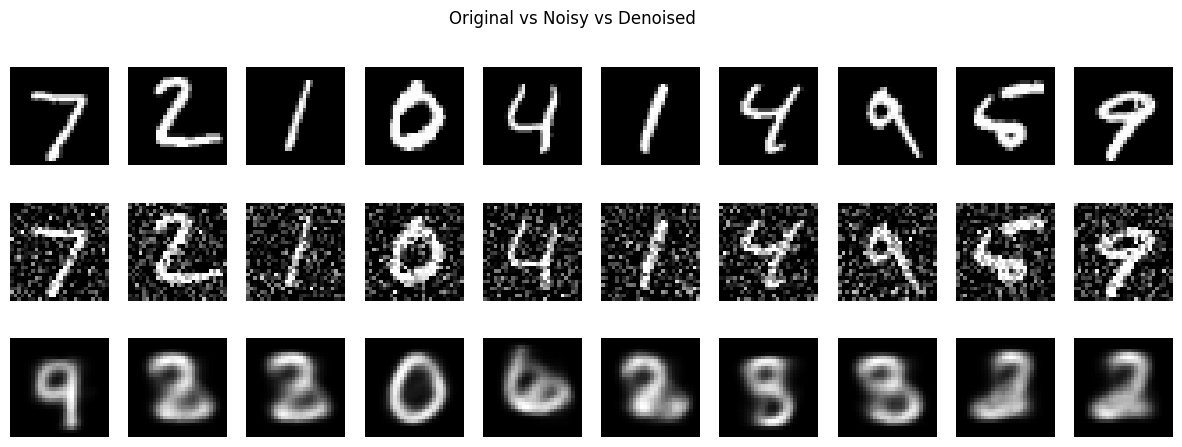

In [ ]:
plt.figure(figsize=(15, 5))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)

    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)

    plt.imshow(
        noisy_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)

    plt.imshow(
        denoised_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Original vs Noisy vs Denoised"
)

plt.show()

## Calculate denoising MSE

In [ ]:
denoising_mse = []

for i in range(10):

    mse = mean_squared_error(
        test_images[i],
        denoised_images[i]
    )

    denoising_mse.append(mse)

print(
    "Average Denoising MSE:",
    np.mean(denoising_mse)
)

Average Denoising MSE: 0.06940632909536362


## PART D — LATENT DIMENSION 16

## Now we create a new VAE with 16 latent dimensions.


## Create VAE 16

In [ ]:
encoder16, decoder16, vae16 = build_vae(16)

print("VAE with latent dimension 16 created!")

VAE with latent dimension 16 created!


## Train VAE 16

In [ ]:
history16 = vae16.fit(
    x_train,
    epochs=20,
    batch_size=128
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - kl_loss: 1.0396 - loss: 34.2178 - reconstruction_loss: 33.1782
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - kl_loss: 2.9546 - loss: 30.1238 - reconstruction_loss: 27.1692
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - kl_loss: 4.1164 - loss: 28.6169 - reconstruction_loss: 24.5005
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 4.6065 - loss: 27.9826 - reconstruction_loss: 23.3761
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - kl_loss: 4.8515 - loss: 27.6716 - reconstruction_loss: 22.8201
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 5.0380 - loss: 27.4164 - reconstruction_loss: 22.3784
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 5.1947 - loss: 27.2617 - reconstruction_loss: 22.0669
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 5.3543 - loss: 27.1128 - reconstruction_loss: 21.7585
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/ste

## Reconstruct using latent 16

In [ ]:
z_mean16, z_log_var16, z16 = encoder16.predict(
    test_images
)

reconstructed16 = decoder16.predict(
    z16
)

print("Latent shape:", z16.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Latent shape: (10, 16)


## Calculate MSE for latent 16

In [ ]:
mse_values_16 = []

for i in range(10):

    mse = mean_squared_error(
        test_images[i],
        reconstructed16[i]
    )

    mse_values_16.append(mse)

average_mse_16 = np.mean(mse_values_16)

print("Latent dimension:", 16)
print("Compression ratio:", 784 / 16, ":1")
print("Average Reconstruction MSE:", average_mse_16)

Latent dimension: 16
Compression ratio: 49.0 :1
Average Reconstruction MSE: 0.03354176366701722


## Display latent 16 reconstruction

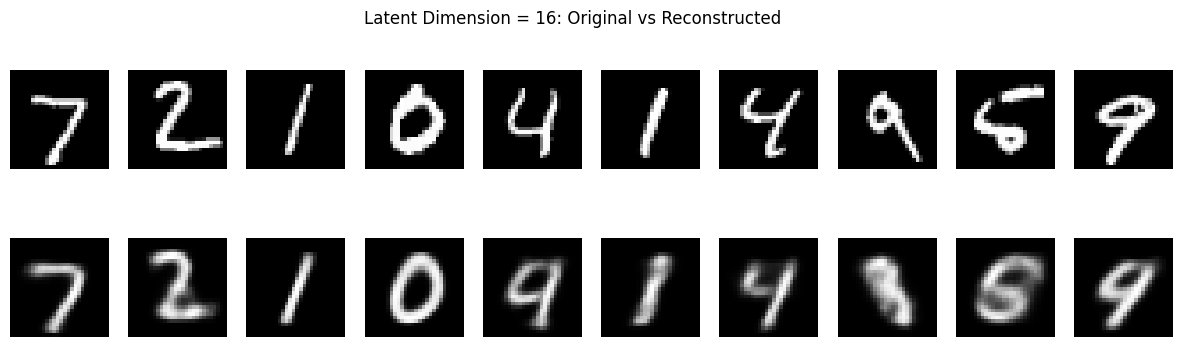

In [ ]:
plt.figure(figsize=(15, 4))

for i in range(10):

    plt.subplot(2, 10, i + 1)

    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed16[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Latent Dimension = 16: Original vs Reconstructed"
)

plt.show()

## PART D — LATENT DIMENSION 32
## Create VAE 32

In [ ]:
encoder32, decoder32, vae32 = build_vae(32)

print("VAE with latent dimension 32 created!")

VAE with latent dimension 32 created!


## Train VAE 32

In [ ]:
history32 = vae32.fit(
    x_train,
    epochs=20,
    batch_size=128
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - kl_loss: 0.7141 - loss: 34.5390 - reconstruction_loss: 33.8250
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - kl_loss: 1.7797 - loss: 31.5161 - reconstruction_loss: 29.7364
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl_loss: 3.0476 - loss: 29.8503 - reconstruction_loss: 26.8027
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - kl_loss: 3.8763 - loss: 28.7756 - reconstruction_loss: 24.8993
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - kl_loss: 4.2837 - loss: 28.2373 - reconstruction_loss: 23.9536
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - kl_loss: 4.5848 - loss: 27.8340 - reconstruction_loss: 23.2492
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 4.7767 - loss: 27.5744 - reconstruction_loss: 22.7977
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - kl_loss: 4.9099 - loss: 27.4011 - reconstruction_loss: 22.4912
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/

## Reconstruct using latent 32

In [ ]:
z_mean32, z_log_var32, z32 = encoder32.predict(
    test_images
)

reconstructed32 = decoder32.predict(
    z32
)

print("Latent shape:", z32.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Latent shape: (10, 32)


## Calculate MSE for latent 32

In [ ]:
mse_values_32 = []

for i in range(10):

    mse = mean_squared_error(
        test_images[i],
        reconstructed32[i]
    )

    mse_values_32.append(mse)

average_mse_32 = np.mean(mse_values_32)

print("Latent dimension:", 32)
print("Compression ratio:", 784 / 32, ":1")
print("Average Reconstruction MSE:", average_mse_32)

Latent dimension: 32
Compression ratio: 24.5 :1
Average Reconstruction MSE: 0.03422305444255471


## Display latent 32 reconstruction

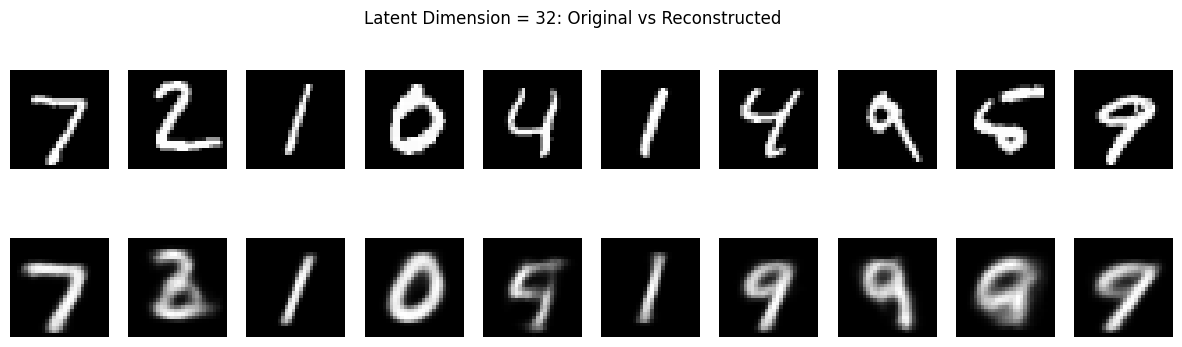

In [ ]:
plt.figure(figsize=(15, 4))

for i in range(10):

    plt.subplot(2, 10, i + 1)

    plt.imshow(
        test_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed32[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Latent Dimension = 32: Original vs Reconstructed"
)

plt.show()

## Create your results table

In [ ]:
results = {
    "Latent Dimension": [2, 16, 32],
    "Original Size": [784, 784, 784],
    "Latent Size": [2, 16, 32],
    "Compression Ratio": [
        "392:1",
        "49:1",
        "24.5:1"
    ],
    "Average Reconstruction MSE": [
        average_mse_2,
        average_mse_16,
        average_mse_32
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

   Latent Dimension  Original Size  Latent Size Compression Ratio  \
0                 2            784            2             392:1   
1                16            784           16              49:1   
2                32            784           32            24.5:1   

   Average Reconstruction MSE  
0                    0.040954  
1                    0.033542  
2                    0.034223  


## Observations

1. The original MNIST images contain 784 pixel values, while the VAE compresses them into a smaller latent representation.

2.  With latent dimension 2, the compression ratio is 392:1. The reconstructed images are blurrier because more information is compressed.

3.  With latent dimension 16, the compression ratio is 49:1 and the reconstruction quality improves compared with latent dimension 2.

4.  With latent dimension 32, the compression ratio is 24.5:1 and the reconstructed images preserve more visual details.

5.  Gaussian noise was added to 10 test images. The VAE was able to reduce some of the noise, although the denoised images were slightly blurred.

## Conclusion

The experiment shows that a Variational Autoencoder can be used for both image compression and basic denoising. A smaller latent dimension provides higher compression but loses more information, while larger latent dimensions improve reconstruction quality at the cost of lower compression.